In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter
import pathlib
from tqdm import tqdm
import numpy as np
import shutil
import random

## Import the dataset

In [2]:
data_dir = '/media/shadab/Others/Liver_Fibrosis_US'

In [3]:
# print the list of files and directories in the specified path
print(os.listdir(data_dir))

['F0', 'F1', 'F2', 'F3', 'F4']


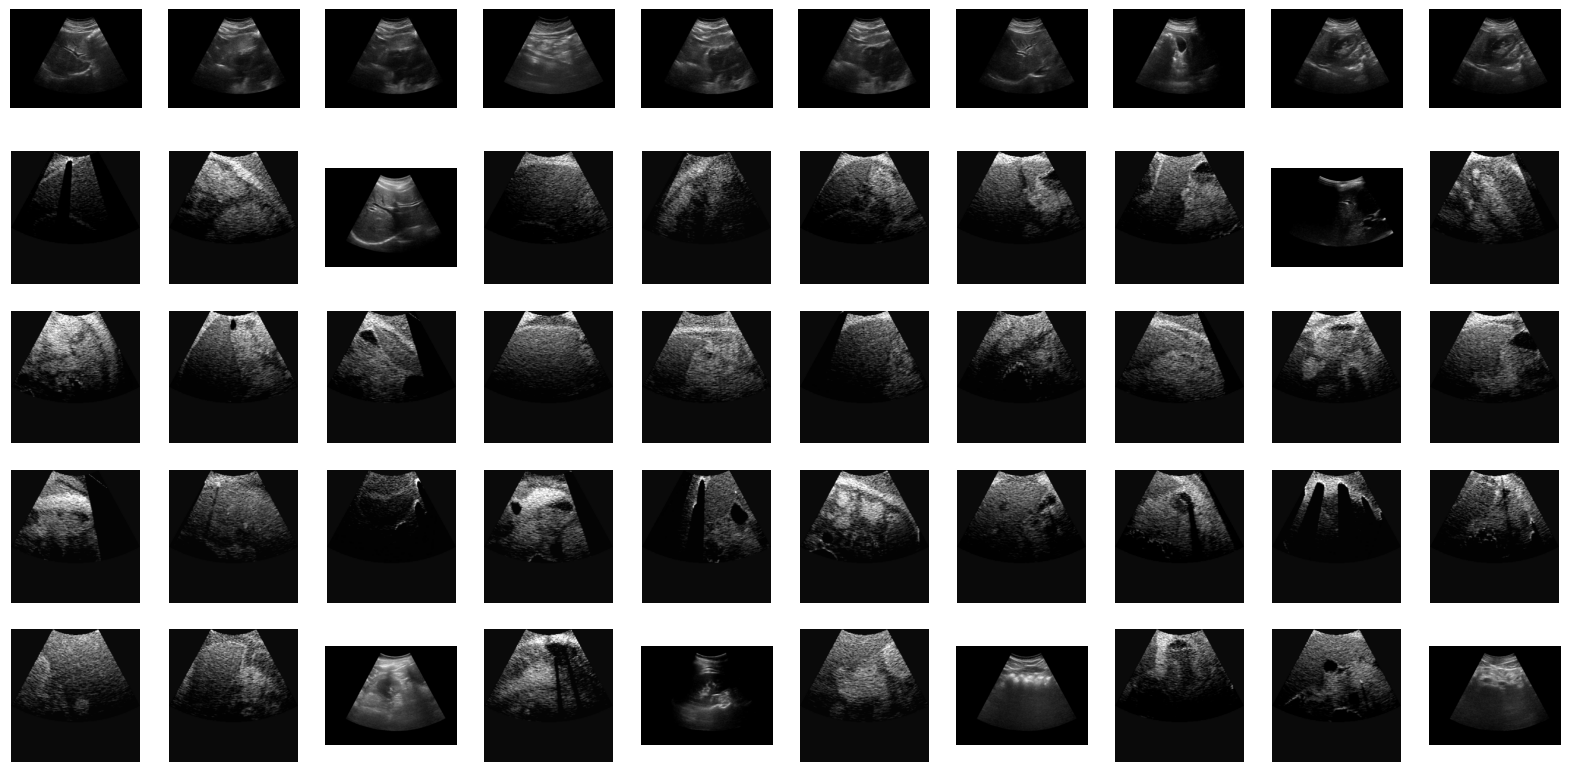

In [4]:
# Print 10 sample images from each class
classes = os.listdir(data_dir)


num_classes = len(classes)
fig, axes = plt.subplots(num_classes, 10, figsize=(20, 2 * num_classes))


for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)[:10]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(cls, size='large')

plt.show()

## Image Resizing

For each class, print the top 10 unique dimensions of the images present in that class folder.

In [5]:
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    shapes = []
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        if not os.path.isfile(fpath):
            continue
        try:
            with Image.open(fpath) as im:
                w, h = im.size  # im.size -> (width, height)
                shapes.append((h, w))  # store as Height x Width
        except Exception:
            # skip unreadable files
            continue

    cnt = Counter(shapes)
    top = cnt.most_common(10)
    print(f"Class: {cls} — top {len(top)} unique dimensions (HxW):")
    for (h, w), c in top:
        print(f"  {h}x{w}  count: {c}")
    print()

Class: F0 — top 1 unique dimensions (HxW):
  480x640  count: 2114

Class: F1 — top 2 unique dimensions (HxW):
  464x449  count: 489
  480x640  count: 372

Class: F2 — top 1 unique dimensions (HxW):
  464x449  count: 793

Class: F3 — top 1 unique dimensions (HxW):
  464x449  count: 857

Class: F4 — top 2 unique dimensions (HxW):
  480x640  count: 973
  464x449  count: 725



Rescale the images to 480x640 pixels

In [6]:
target_h, target_w = 480, 640
resample_method = 'bicubic'  # 'bilinear' or 'bicubic'

_resample_map = {
    'bilinear': Image.BILINEAR,
    'bicubic': Image.BICUBIC,
}

resample = _resample_map.get(resample_method.lower(), Image.BILINEAR)

output_root = os.path.join(os.path.dirname(data_dir), 'Liver_Fibrosis_US_480x640')
os.makedirs(output_root, exist_ok=True)

# build list of files to process (preserves class subfolders)
file_list = []
for cls in classes:
    cls_in = os.path.join(data_dir, cls)
    if not os.path.isdir(cls_in):
        continue
    for fname in os.listdir(cls_in):
        in_path = os.path.join(cls_in, fname)
        if os.path.isfile(in_path):
            file_list.append((cls, fname))

# process with progress bar
for cls, fname in tqdm(file_list, desc="Resizing images", unit="img"):
    cls_in = os.path.join(data_dir, cls)
    cls_out = os.path.join(output_root, cls)
    os.makedirs(cls_out, exist_ok=True)

    in_path = os.path.join(cls_in, fname)
    out_path = os.path.join(cls_out, fname)

    try:
        with Image.open(in_path) as im:
            # convert to RGB if image has alpha or other modes; preserve grayscale if 'L'
            mode = 'L' if im.mode == 'L' else 'RGB'
            if im.mode != mode:
                im = im.convert(mode)

            w, h = im.size  # (width, height)
            # Scale to target height so every image will need only horizontal padding (left/right)
            scale = target_h / h
            new_w = int(round(w * scale))
            new_h = target_h
            resized = im.resize((new_w, new_h), resample=resample)

            # If scaled width somehow exceeds target width 
            # fall back to fit-by-width and pad vertically
            if new_w > target_w:
                scale = target_w / w
                new_w = target_w
                new_h = int(round(h * scale))
                resized = im.resize((new_w, new_h), resample=resample)

            # create black canvas and paste centered
            fill = 0 if mode == 'L' else (0, 0, 0)
            canvas = Image.new(mode, (target_w, target_h), color=fill)
            left = (target_w - new_w) // 2
            top = (target_h - new_h) // 2
            canvas.paste(resized, (left, top))

            # save 
            try:
                canvas.save(out_path)
            except Exception:
                # if save fails for some formats, force PNG
                canvas.convert('RGB').save(out_path, format='PNG')
    except Exception as e:
        # skip unreadable files
        print(f"skip {in_path}: {e}")

print("Done. Resized dataset written to:", output_root)

Resizing images: 100%|██████████| 6323/6323 [00:33<00:00, 187.84img/s] 

Done. Resized dataset written to: /media/shadab/Others/Liver_Fibrosis_US_480x640


Verify the resized images

In [7]:
data_dir = output_root
classes = os.listdir(data_dir)

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    shapes = []
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        fpath = os.path.join(cls_path, fname)
        if not os.path.isfile(fpath):
            continue
        try:
            with Image.open(fpath) as im:
                w, h = im.size  # im.size -> (width, height)
                shapes.append((h, w))  # store as Height x Width
        except Exception:
            # skip unreadable files
            continue

    cnt = Counter(shapes)
    top = cnt.most_common(10)
    print(f"Class: {cls} — top {len(top)} unique dimensions (HxW):")
    for (h, w), c in top:
        print(f"  {h}x{w}  count: {c}")
    print()

Class: F0 — top 1 unique dimensions (HxW):
  480x640  count: 2114

Class: F1 — top 1 unique dimensions (HxW):
  480x640  count: 861

Class: F2 — top 1 unique dimensions (HxW):
  480x640  count: 793

Class: F3 — top 1 unique dimensions (HxW):
  480x640  count: 857

Class: F4 — top 1 unique dimensions (HxW):
  480x640  count: 1698



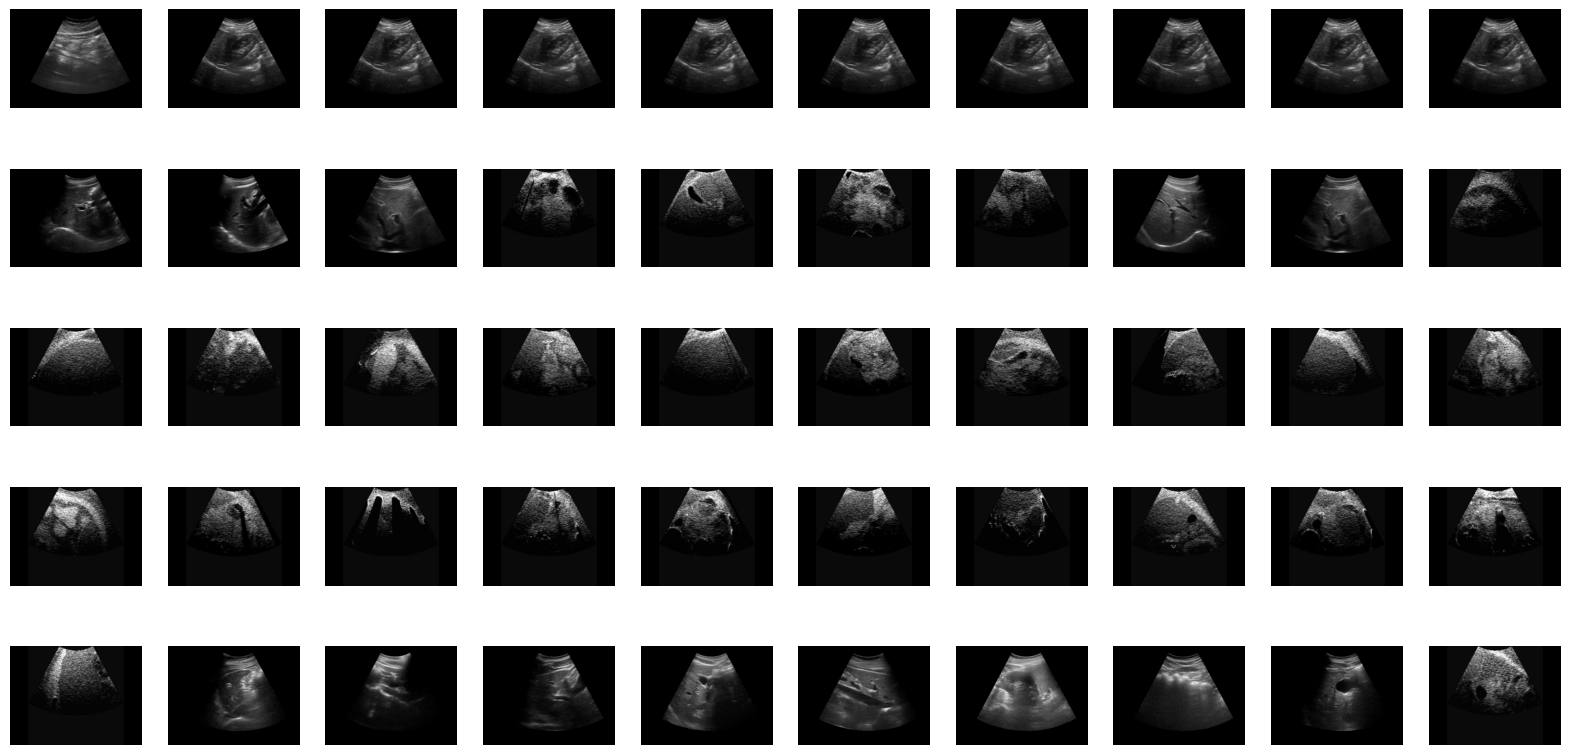

In [8]:
num_classes = len(classes)
fig, axes = plt.subplots(num_classes, 10, figsize=(20, 2 * num_classes))

for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)[:10]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(cls, size='large')

plt.show()

## Intensity Normalization

In [9]:
resized_root = os.path.join(os.path.dirname(data_dir), 'Liver_Fibrosis_US_480x640')
processed_root = os.path.join(os.path.dirname(data_dir), 'Liver_Fibrosis_US_processed')
os.makedirs(processed_root, exist_ok=True)

classes = [c for c in os.listdir(resized_root) if os.path.isdir(os.path.join(resized_root, c))]

file_list = []
for cls in classes:
    cls_in = os.path.join(resized_root, cls)
    for fname in os.listdir(cls_in):
        in_path = os.path.join(cls_in, fname)
        if os.path.isfile(in_path):
            file_list.append((cls, fname))

from tqdm import tqdm
for cls, fname in tqdm(file_list, desc="Normalizing images", unit="img"):
    cls_in = os.path.join(resized_root, cls)
    cls_out = os.path.join(processed_root, cls)
    os.makedirs(cls_out, exist_ok=True)

    in_path = os.path.join(cls_in, fname)
    out_path = os.path.join(cls_out, fname)

    try:
        with Image.open(in_path) as im:
            # handle grayscale and color separately, keep mode
            if im.mode == 'L':
                arr = np.array(im).astype(np.float32)
                mn, mx = float(arr.min()), float(arr.max())
                if mx > mn:
                    arr = (arr - mn) / (mx - mn) * 255.0
                arr = np.round(arr).astype(np.uint8)
                out_im = Image.fromarray(arr, mode='L')
            else:
                # convert to RGB and do per-channel min-max scaling
                rgb = np.array(im.convert('RGB')).astype(np.float32)
                for c in range(3):
                    ch = rgb[..., c]
                    mn, mx = float(ch.min()), float(ch.max())
                    if mx > mn:
                        rgb[..., c] = (ch - mn) / (mx - mn) * 255.0
                rgb = np.round(rgb).astype(np.uint8)
                out_im = Image.fromarray(rgb, mode='RGB')

            try:
                out_im.save(out_path)
            except Exception:
                out_im.convert('RGB').save(out_path, format='PNG')
    except Exception as e:
        print(f"skip {in_path}: {e}")

print("Normalized images written to:", processed_root)

Normalizing images:   0%|          | 0/6323 [00:00<?, ?img/s]/tmp/ipykernel_963924/2970210538.py:33: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  out_im = Image.fromarray(arr, mode='L')
Normalizing images:  32%|███▏      | 2048/6323 [00:02<00:05, 733.89img/s]/tmp/ipykernel_963924/2970210538.py:43: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  out_im = Image.fromarray(rgb, mode='RGB')
Normalizing images: 100%|██████████| 6323/6323 [00:35<00:00, 180.52img/s]

Normalized images written to: /media/shadab/Others/Liver_Fibrosis_US_processed


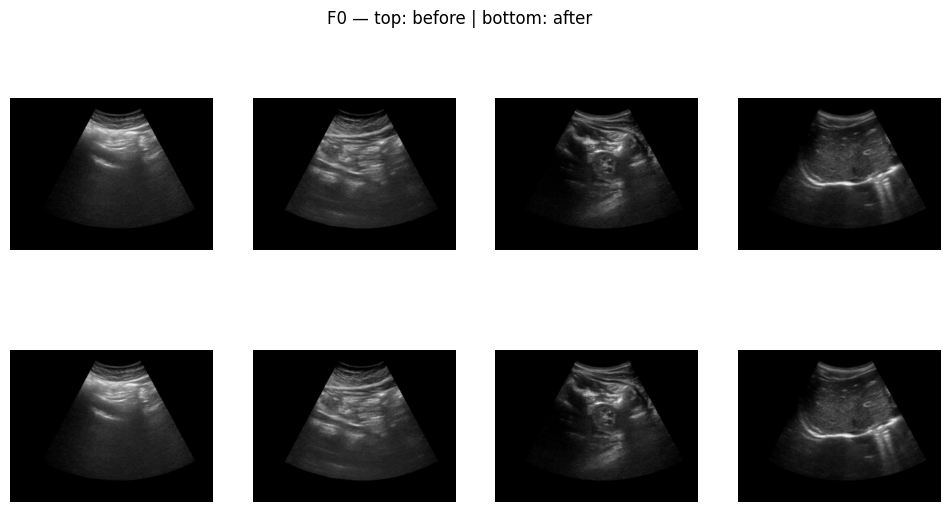

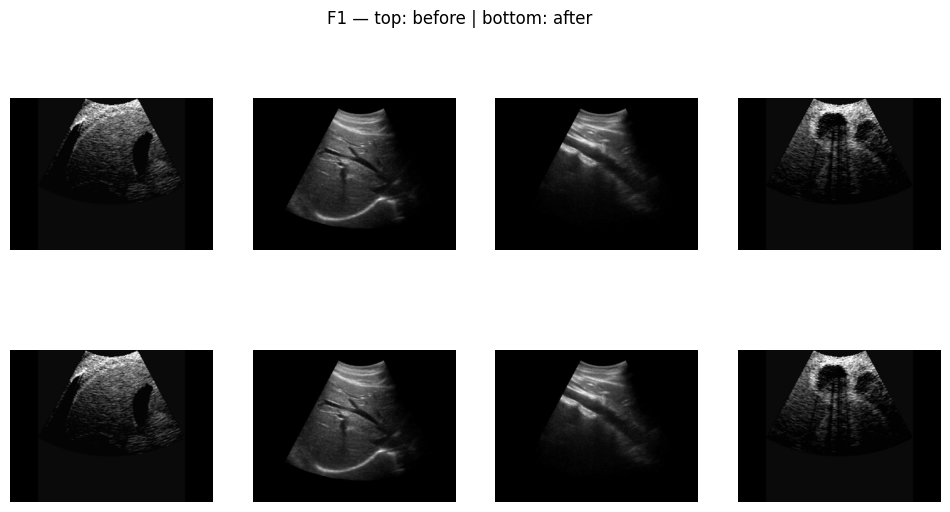

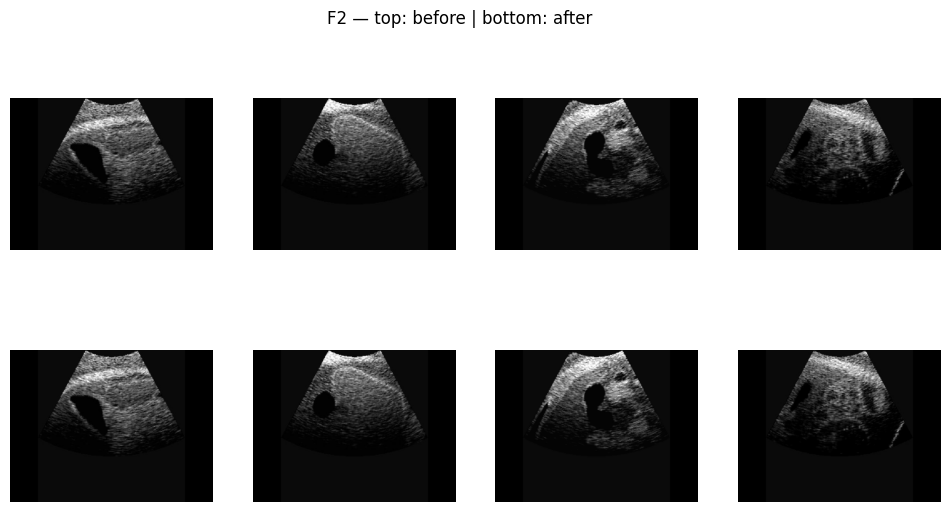

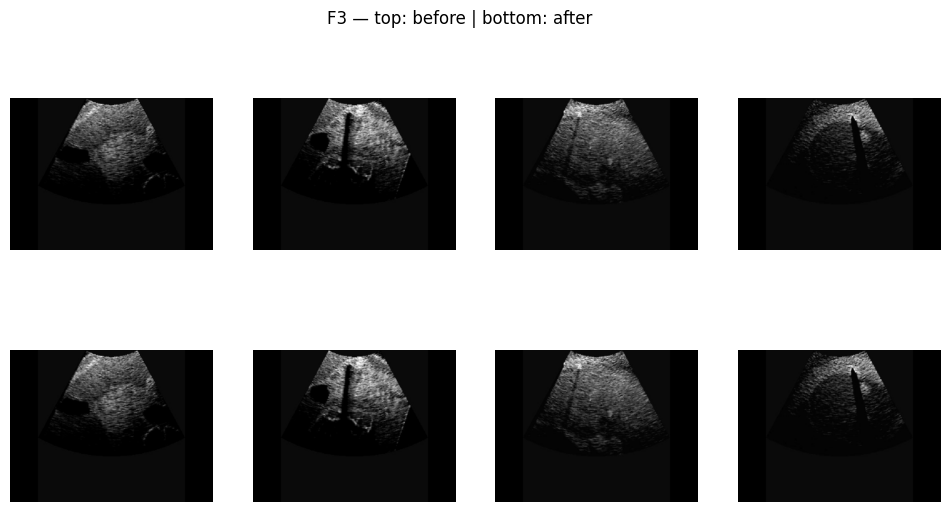

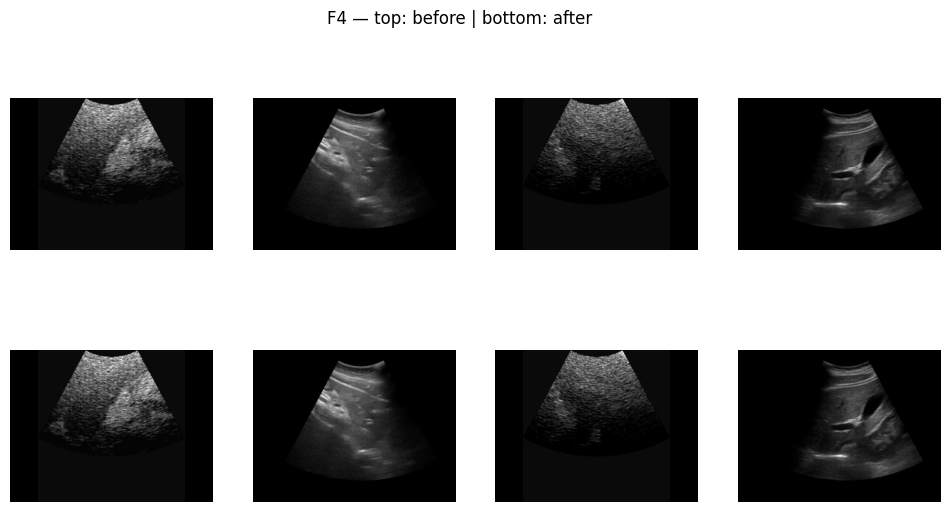

In [ ]:
# Display random 4 before/after per class for quick visual check
n_show = 4
for cls in classes:
    cls_resized = os.path.join(resized_root, cls)
    cls_processed = os.path.join(processed_root, cls)
    fnames = [f for f in os.listdir(cls_resized) if os.path.isfile(os.path.join(cls_resized, f))]
    if not fnames:
        continue
    sample = random.sample(fnames, min(n_show, len(fnames)))
    cols = len(sample)
    fig, axes = plt.subplots(2, cols, figsize=(3 * cols, 6))
    fig.suptitle(f"{cls} — top: before | bottom: after", fontsize=12)
    for j, fname in enumerate(sample):
        before = mpimg.imread(os.path.join(cls_resized, fname))
        after = mpimg.imread(os.path.join(cls_processed, fname))
        axes[0, j].imshow(before, cmap='gray' if before.ndim == 2 else None)
        axes[0, j].axis('off')
        axes[1, j].imshow(after, cmap='gray' if after.ndim == 2 else None)
        axes[1, j].axis('off')
    plt.show()

Computing histograms per class (before -> resized, after -> processed)...


Classes: 100%|██████████| 5/5 [00:18<00:00,  3.64s/it]


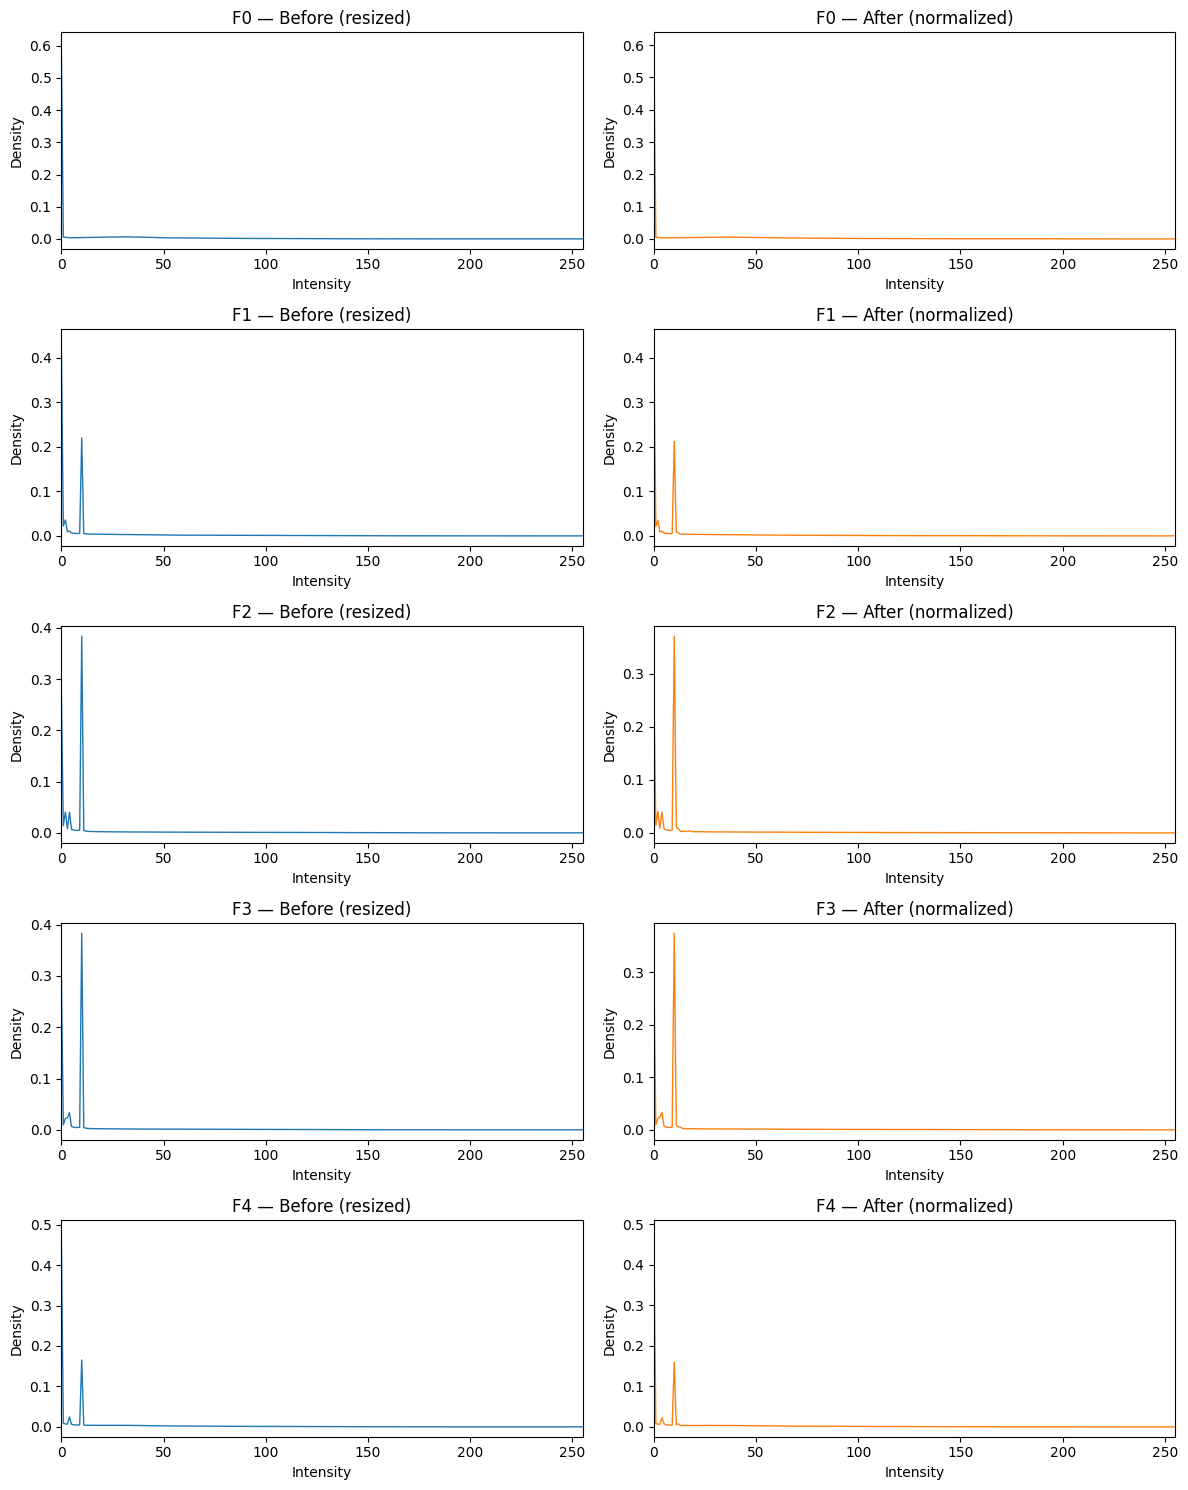

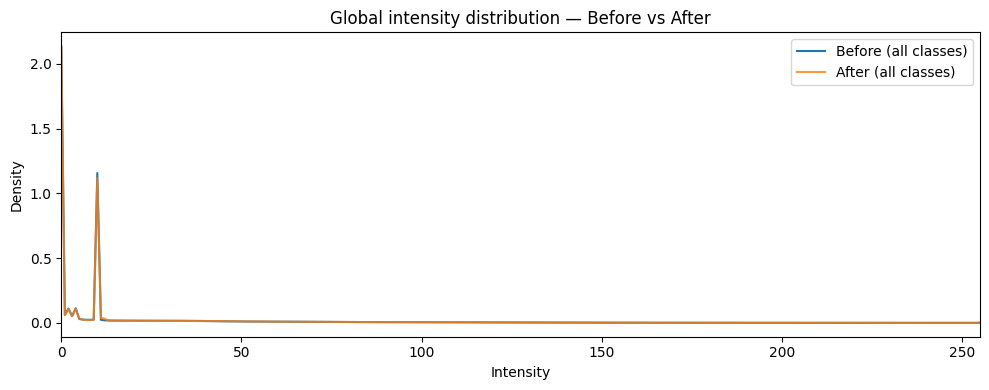

In [ ]:
resized_root = os.path.join(os.path.dirname(data_dir), 'Liver_Fibrosis_US_480x640')
processed_root = os.path.join(os.path.dirname(data_dir), 'Liver_Fibrosis_US_processed')

classes = [c for c in os.listdir(resized_root) if os.path.isdir(os.path.join(resized_root, c))]

def class_histogram(dir_root, cls, nbins=256):
    hist = np.zeros(nbins, dtype=np.int64)
    cls_dir = os.path.join(dir_root, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        if not os.path.isfile(fpath):
            continue
        try:
            with Image.open(fpath) as im:
                # convert to grayscale for a single intensity distribution
                arr = np.array(im.convert('L')).ravel()
                # bincount is fast and memory efficient
                binc = np.bincount(arr, minlength=nbins)
                hist[:len(binc)] += binc
        except Exception:
            continue
    # convert to density (sum = 1) to compare different class sizes
    total = hist.sum()
    if total > 0:
        return hist.astype(np.float64) / total
    return hist.astype(np.float64)

# compute histograms
before_hists = {}
after_hists = {}
print("Computing histograms per class (before -> resized, after -> processed)...")
for cls in tqdm(classes, desc="Classes"):
    before_hists[cls] = class_histogram(resized_root, cls)
    after_hists[cls]  = class_histogram(processed_root, cls)

x = np.arange(256)

# Plot per-class before/after side-by-side
n = len(classes)
fig, axes = plt.subplots(n, 2, figsize=(12, 3 * n), squeeze=False)
for i, cls in enumerate(classes):
    ax_before = axes[i, 0]
    ax_after = axes[i, 1]

    ax_before.plot(x, before_hists[cls], color='C0', lw=1)
    ax_before.set_title(f"{cls} — Before (resized)")
    ax_before.set_xlim(0, 255)
    ax_before.set_xlabel("Intensity")
    ax_before.set_ylabel("Density")

    ax_after.plot(x, after_hists[cls], color='C1', lw=1)
    ax_after.set_title(f"{cls} — After (normalized)")
    ax_after.set_xlim(0, 255)
    ax_after.set_xlabel("Intensity")
    ax_after.set_ylabel("Density")

plt.tight_layout()
plt.show()

# Plot aggregated global histogram overlay for quick summary
global_before = sum(before_hists.values())
global_after  = sum(after_hists.values())

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(x, global_before, label='Before (all classes)', color='C0')
ax.plot(x, global_after, label='After (all classes)', color='C1', alpha=0.8)
ax.set_title("Global intensity distribution — Before vs After")
ax.set_xlabel("Intensity")
ax.set_ylabel("Density")
ax.set_xlim(0, 255)
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Delete the resized folder (Liver_Fibrosis_US_480x640)
try:
    shutil.rmtree(resized_root)
    print("Deleted resized folder:", resized_root)
except Exception as e:
    print("Failed to delete resized folder:", e)

Deleted resized folder: /media/shadab/Others/Liver_Fibrosis_US_480x640
